In [21]:
import numpy as np
import matplotlib.pyplot as plt

def plot_psd_funcs(psd_funcs, l_max=1.0, n_points=200):
    x = np.linspace(0, l_max, n_points)

    plt.figure(figsize=(6, 4))

    for i, f in enumerate(psd_funcs):
        y = f(x, l_max)
        plt.plot(x, y, label=f"PSD {i}")

    plt.xlabel("λ (eigenvalues)")
    plt.ylabel("PSD")
    plt.title("Porównanie funkcji PSD")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
from codes.clustering import gmm_mixed_signal_experiment
from codes.generation import generate_nn_graph
graph = generate_nn_graph()
probs = [0.5,0.5]
psd_funcs ={
    "easy":[
        lambda x, lm: np.exp(-8.0 * (x / lm - 0.35)**2),
        lambda x, lm: np.exp(-8.0 * (x / lm - 0.55)**2)
        ], 
    "medium" :[
        lambda x, lm: np.exp(-20.0 * (x / lm - 0.4)**2),
        lambda x, lm: np.exp(-20.0 * (x / lm - 0.5)**2)    
        ], 
    "hard" :[
        lambda x, lm: (
            np.exp(-15 * (x / lm - 0.3)**2) +
            0.8 * np.exp(-15 * (x / lm - 0.7)**2)
        ),
        lambda x, lm: (
            np.exp(-15 * (x / lm - 0.5)**2) +
            0.6 * np.exp(-15 * (x / lm - 0.8)**2)
        )
    ]
}

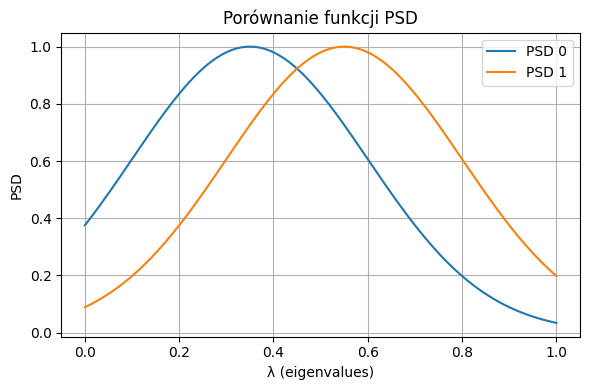

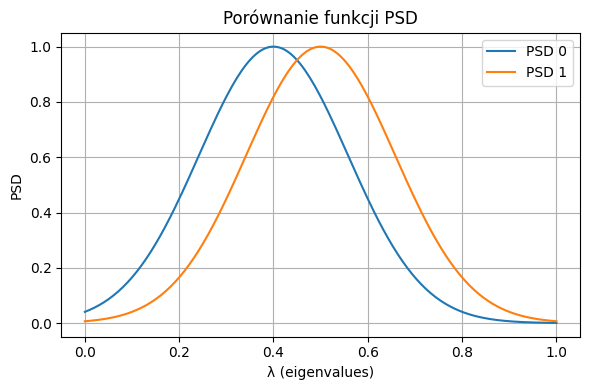

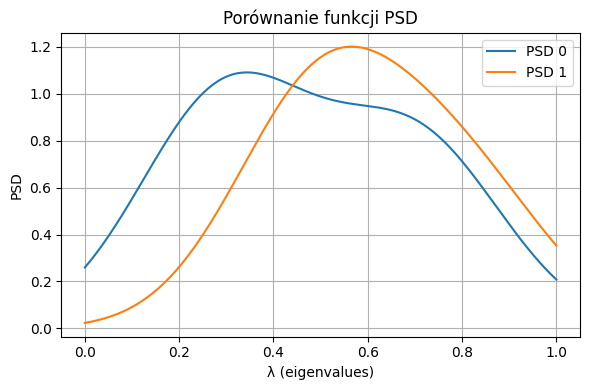

In [27]:
for fun in psd_funcs.keys():
    plot_psd_funcs(psd_funcs[fun])

In [14]:
r = gmm_mixed_signal_experiment(graph=graph, psd_s= psd_funcs["hard"], probs= probs, n_runs=100, p =1)
r["mean_acc"]

np.float64(0.92964)

In [24]:
r_1= gmm_mixed_signal_experiment(graph=graph, psd_s= psd_funcs["medium"], probs= probs, n_runs=100, p =0.2)
r_1["mean_acc"]

np.float64(0.99268)

In [28]:
r_2= gmm_mixed_signal_experiment(graph=graph, psd_s= psd_funcs["hard"], probs= probs, n_runs=100, p =0.2)
r_2["mean_acc"]

np.float64(0.6843)